# Sprite Generator - Complete GPU Training
VQ-VAE (200 epochs) + Transformer (200 epochs) with:
- CosineAnnealingLR scheduler, gradient clipping, weight decay for VQ-VAE
- Linear warmup + CosineAnnealingLR for Transformer
- Expanded codebook (512), scaled Transformer (d_model=512, n_heads=8)
- Batch size 128, on-the-fly augmentations

In [15]:
import os, sys, torch, json, warnings, math
from pathlib import Path
warnings.filterwarnings("ignore")

!pip install -q datasets huggingface_hub torchvision pillow tqdm

if not os.path.exists('/kaggle/working/sprite-gen'):
    !git clone https://github.com/MANI8148/sprite-generator.git /kaggle/working/sprite-gen
sys.path.insert(0, '/kaggle/working/sprite-gen')

In [19]:
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN", "")

HF_DATASET = "darklord8777/sprites"
HF_MODEL_REPO = "darklord8777/sprite-generator-model"

VQVAE_EPOCHS = 150
TRANSFORMER_EPOCHS = 100
BATCH_SIZE = 128
LR = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"HF_TOKEN set: {bool(HF_TOKEN)}")

Device: cuda
GPU: Tesla T4
Memory: 15.64 GB
HF_TOKEN set: True


# Step 1: Dataset (with on-the-fly augmentations, RGBA-safe)

In [13]:
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from datasets import load_dataset
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.nn as nn

class SpriteDataset(torch.utils.data.Dataset):
    def __init__(self, hf_path, split="train", image_size=32, augment=True):
        self.dataset = load_dataset(hf_path, split=split)
        self.image_size = image_size
        self.augment = augment
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        item = self.dataset[idx]
        img = item["image"].convert("RGBA")
        img = img.resize((self.image_size, self.image_size), Image.NEAREST)
        img_t = transforms.ToTensor()(img)
        if self.augment:
            rgb, a = img_t[:3], img_t[3:]
            if torch.rand(1).item() > 0.3:
                rgb = TF.adjust_brightness(rgb, 1.0 + torch.empty(1).uniform_(-0.1, 0.1).item())
            if torch.rand(1).item() > 0.3:
                rgb = TF.adjust_contrast(rgb, 1.0 + torch.empty(1).uniform_(-0.1, 0.1).item())
            img_t = torch.cat([rgb, a])
            if torch.rand(1).item() > 0.3:
                dx, dy = int(torch.empty(1).uniform_(-2, 3).item()), int(torch.empty(1).uniform_(-2, 3).item())
                img_t = torch.roll(img_t, shifts=(dy, dx), dims=(1, 2))
                if dx > 0: img_t[:, :, :dx] = 0
                elif dx < 0: img_t[:, :, dx:] = 0
                if dy > 0: img_t[:, :dy, :] = 0
                elif dy < 0: img_t[:, dy:, :] = 0
        return img_t

ds = SpriteDataset(HF_DATASET, augment=True)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"Dataset: {len(ds)} sprites, {len(dl)} batches/epoch")

Dataset: 26894 sprites, 211 batches/epoch


# Step 2: Train VQ-VAE with EMA + CosineAnnealingLR

In [20]:
import torch.nn.functional as F
from models.vqvae.model import VQVAE

# --- Upgraded config ---
VQVAE_HIDDEN_DIM = 256      # was 128
VQVAE_LATENT_DIM = 96       # was 64
VQVAE_LR = 2e-4             # was 3e-4
RECON_WEIGHT = 1.0
VQ_WEIGHT = 0.25            # downweight vs default 1:1
L1_WEIGHT = 0.5             # blended with model's internal MSE recon loss

vqvae = VQVAE(in_channels=4, hidden_dim=VQVAE_HIDDEN_DIM, latent_dim=VQVAE_LATENT_DIM, num_embeddings=512).to(device)
optimizer = torch.optim.Adam(vqvae.parameters(), lr=VQVAE_LR, weight_decay=1e-5)
scheduler_v = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=VQVAE_EPOCHS)

ckpt_dir_vqvae = Path("/kaggle/working/checkpoints/vqvae")
ckpt_dir_vqvae.mkdir(parents=True, exist_ok=True)

recon_key = None  # auto-detected on first batch
best_recon_loss = float("inf")

for epoch in range(VQVAE_EPOCHS):
    vqvae.train()
    total_loss = total_recon = total_vq = 0
    pbar = tqdm(dl, desc=f"VQVAE Epoch {epoch+1}/{VQVAE_EPOCHS}")
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = vqvae(batch)

        # Auto-detect the reconstructed-image key once
        if recon_key is None:
            for k in ("recon", "x_recon", "reconstruction", "x_hat"):
                if k in out:
                    recon_key = k
                    break
            if recon_key is None:
                print("⚠️  Could not find reconstructed image in output dict. Keys:", list(out.keys()))
                print("    Falling back to model's built-in loss only (no L1 blend).")

        # Reweighted loss: recon + downweighted vq + optional L1 sharpening term
        loss = RECON_WEIGHT * out["recon_loss"] + VQ_WEIGHT * out["vq_loss"]
        if recon_key is not None:
            l1 = F.l1_loss(out[recon_key], batch)
            loss = loss + L1_WEIGHT * l1

        loss.backward()
        torch.nn.utils.clip_grad_norm_(vqvae.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_recon += out["recon_loss"].item()
        total_vq += out["vq_loss"].item()
        pbar.set_postfix({"loss": loss.item(), "recon": out["recon_loss"].item()})

    scheduler_v.step()
    avg_loss = total_loss / len(dl)
    avg_recon = total_recon / len(dl)
    avg_vq = total_vq / len(dl)
    print(f"VQVAE Epoch {epoch+1}: loss={avg_loss:.6f} recon={avg_recon:.6f} vq={avg_vq:.6f} lr={scheduler_v.get_last_lr()[0]:.2e}")

    ckpt_path = ckpt_dir_vqvae / f"vqvae_epoch_{epoch+1:03d}.pt"
    torch.save({
        "epoch": epoch, "model_state": vqvae.state_dict(), "optimizer_state": optimizer.state_dict(),
        "loss": avg_loss, "recon_loss": avg_recon,
        "config": {"hidden_dim": VQVAE_HIDDEN_DIM, "latent_dim": VQVAE_LATENT_DIM, "num_embeddings": 512},
    }, ckpt_path)

    # Track best-by-reconstruction (not just last epoch)
    is_best = avg_recon < best_recon_loss
    if is_best:
        best_recon_loss = avg_recon
        best_path = ckpt_dir_vqvae / "vqvae_best.pt"
        torch.save({
            "epoch": epoch, "model_state": vqvae.state_dict(), "optimizer_state": optimizer.state_dict(),
            "loss": avg_loss, "recon_loss": avg_recon,
            "config": {"hidden_dim": VQVAE_HIDDEN_DIM, "latent_dim": VQVAE_LATENT_DIM, "num_embeddings": 512},
        }, best_path)

    # Periodic HF push (same pattern as before)
    if HF_TOKEN and (epoch + 1) % 20 == 0:
        from huggingface_hub import HfApi
        api = HfApi(token=HF_TOKEN)
        api.upload_file(path_or_fileobj=str(ckpt_path), path_in_repo="vqvae_latest.pt", repo_id=HF_MODEL_REPO, repo_type="model")
        if is_best:
            api.upload_file(path_or_fileobj=str(best_path), path_in_repo="vqvae_best.pt", repo_id=HF_MODEL_REPO, repo_type="model")
        print(f"  -> Pushed checkpoint to HF (epoch {epoch+1}, best_recon={best_recon_loss:.6f})")

if HF_TOKEN:
    from huggingface_hub import HfApi
    api = HfApi(token=HF_TOKEN)
    api.upload_file(path_or_fileobj=str(ckpt_dir_vqvae / f"vqvae_epoch_{VQVAE_EPOCHS:03d}.pt"), path_in_repo="vqvae_latest.pt", repo_id=HF_MODEL_REPO, repo_type="model")
    api.upload_file(path_or_fileobj=str(ckpt_dir_vqvae / "vqvae_best.pt"), path_in_repo="vqvae_best.pt", repo_id=HF_MODEL_REPO, repo_type="model")
    print("VQ-VAE final + best checkpoints pushed to HF")
print(f"VQ-VAE training complete! Best recon loss: {best_recon_loss:.6f}")

VQVAE Epoch 1/150: 100%|██████████| 211/211 [00:35<00:00,  5.87it/s, loss=5.08e+3, recon=0.0937]


VQVAE Epoch 1: loss=509.161430 recon=0.074316 vq=2036.013038 lr=2.00e-04


VQVAE Epoch 2/150: 100%|██████████| 211/211 [00:35<00:00,  5.96it/s, loss=6.2, recon=0.0546]   


VQVAE Epoch 2: loss=2227.513655 recon=0.065265 vq=8909.490368 lr=2.00e-04


VQVAE Epoch 3/150: 100%|██████████| 211/211 [00:36<00:00,  5.74it/s, loss=8.74, recon=0.063] 


...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

VQ-VAE final + best checkpoints pushed to HF
VQ-VAE training complete! Best recon loss: 0.013502


In [5]:
from models.vqvae.model import VQVAE

vqvae = VQVAE(in_channels=4, hidden_dim=128, latent_dim=64, num_embeddings=512).to(device)
optimizer = torch.optim.Adam(vqvae.parameters(), lr=LR, weight_decay=1e-5)
scheduler_v = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=VQVAE_EPOCHS)

ckpt_dir_vqvae = Path("/kaggle/working/checkpoints/vqvae")
ckpt_dir_vqvae.mkdir(parents=True, exist_ok=True)

for epoch in range(VQVAE_EPOCHS):
    vqvae.train()
    total_loss = total_recon = total_vq = 0
    pbar = tqdm(dl, desc=f"VQVAE Epoch {epoch+1}/{VQVAE_EPOCHS}")
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = vqvae(batch)
        out["loss"].backward()
        torch.nn.utils.clip_grad_norm_(vqvae.parameters(), 1.0)
        optimizer.step()
        total_loss += out["loss"].item()
        total_recon += out["recon_loss"].item()
        total_vq += out["vq_loss"].item()
        pbar.set_postfix({"loss": out["loss"].item(), "recon": out["recon_loss"].item()})
    scheduler_v.step()
    avg_loss = total_loss / len(dl)
    avg_recon = total_recon / len(dl)
    print(f"VQVAE Epoch {epoch+1}: loss={avg_loss:.6f} recon={avg_recon:.6f} lr={scheduler_v.get_last_lr()[0]:.2e}")
    
    ckpt_path = ckpt_dir_vqvae / f"vqvae_epoch_{epoch+1:03d}.pt"
    torch.save({"epoch": epoch, "model_state": vqvae.state_dict(), "optimizer_state": optimizer.state_dict(), "loss": avg_loss, "config": {"hidden_dim": 128, "latent_dim": 64, "num_embeddings": 512}}, ckpt_path)
    # Periodic HF push to prevent total loss on Kaggle timeout
    if HF_TOKEN and (epoch + 1) % 20 == 0:
        from huggingface_hub import HfApi
        HfApi(token=HF_TOKEN).upload_file(path_or_fileobj=str(ckpt_path), path_in_repo="vqvae_latest.pt", repo_id=HF_MODEL_REPO, repo_type="model")
        print(f"  -> Pushed checkpoint to HF (epoch {epoch+1})")

if HF_TOKEN:
    from huggingface_hub import HfApi
    HfApi(token=HF_TOKEN).upload_file(path_or_fileobj=str(ckpt_dir_vqvae / f"vqvae_epoch_{VQVAE_EPOCHS:03d}.pt"), path_in_repo="vqvae_latest.pt", repo_id=HF_MODEL_REPO, repo_type="model")
    print("VQ-VAE final checkpoint pushed to HF")
print("VQ-VAE training complete!")

VQVAE Epoch 1/150: 100%|██████████| 211/211 [00:28<00:00,  7.44it/s, loss=2.16, recon=0.0496]


VQVAE Epoch 1: loss=3.193913 recon=0.059476 lr=3.00e-04


VQVAE Epoch 2/150: 100%|██████████| 211/211 [00:26<00:00,  7.86it/s, loss=0.699, recon=0.0282]


VQVAE Epoch 2: loss=1.036845 recon=0.036311 lr=3.00e-04


VQVAE Epoch 3/150: 100%|██████████| 211/211 [00:26<00:00,  7.87it/s, loss=0.637, recon=0.0346]


...

VQVAE Epoch 150/150: 100%|██████████| 211/211 [00:26<00:00,  7.84it/s, loss=0.16, recon=0.0119]  


VQVAE Epoch 150: loss=0.154409 recon=0.010811 lr=0.00e+00


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

VQ-VAE final checkpoint pushed to HF
VQ-VAE training complete!


In [1]:
from collections import Counter
all_tokens = []
for seq in token_sequences:  # your saved 26894 sequences
    all_tokens.extend(seq.flatten().tolist())
usage = Counter(all_tokens)
print(f"Unique codes used: {len(usage)} / {codebook_size}")
print(f"Top 10: {usage.most_common(10)}")

NameError: name 'token_sequences' is not defined

In [22]:
from models.vqvae.model import VQVAE
from huggingface_hub import hf_hub_download

vqvae = VQVAE(in_channels=4, hidden_dim=256, latent_dim=96, num_embeddings=512).to(device)

ckpt_path = hf_hub_download(
    repo_id=HF_MODEL_REPO,
    filename="vqvae_best.pt",
    repo_type="model",
    token=HF_TOKEN,
)
checkpoint = torch.load(ckpt_path, map_location=device)

cfg = checkpoint["config"]
vqvae = VQVAE(
    in_channels=4,
    hidden_dim=cfg["hidden_dim"],
    latent_dim=cfg["latent_dim"],
    num_embeddings=cfg["num_embeddings"],
).to(device)
vqvae.load_state_dict(checkpoint["model_state"])
vqvae.eval()

print(f"Loaded epoch {checkpoint['epoch']}, recon_loss={checkpoint.get('recon_loss', checkpoint.get('loss')):.6f}")
print(f"Config: {cfg}")

vqvae_best.pt:   0%|          | 0.00/83.7M [00:00<?, ?B/s]

Loaded epoch 146, recon_loss=0.013502
Config: {'hidden_dim': 256, 'latent_dim': 96, 'num_embeddings': 512}


Codebook usage: 262/512 codes used (51.2%)
Top 10 most-used codes: [(32, 1903), (195, 1901), (152, 1871), (96, 1868), (218, 1854), (374, 1809), (254, 1672), (11, 1565), (39, 1542), (141, 1531)]
Bottom 10 (of used) codes: [(111, 1), (460, 1), (29, 1), (467, 1), (203, 1), (0, 1), (119, 1), (352, 1), (113, 1), (159, 1)]
✅ Codebook usage looks healthy.


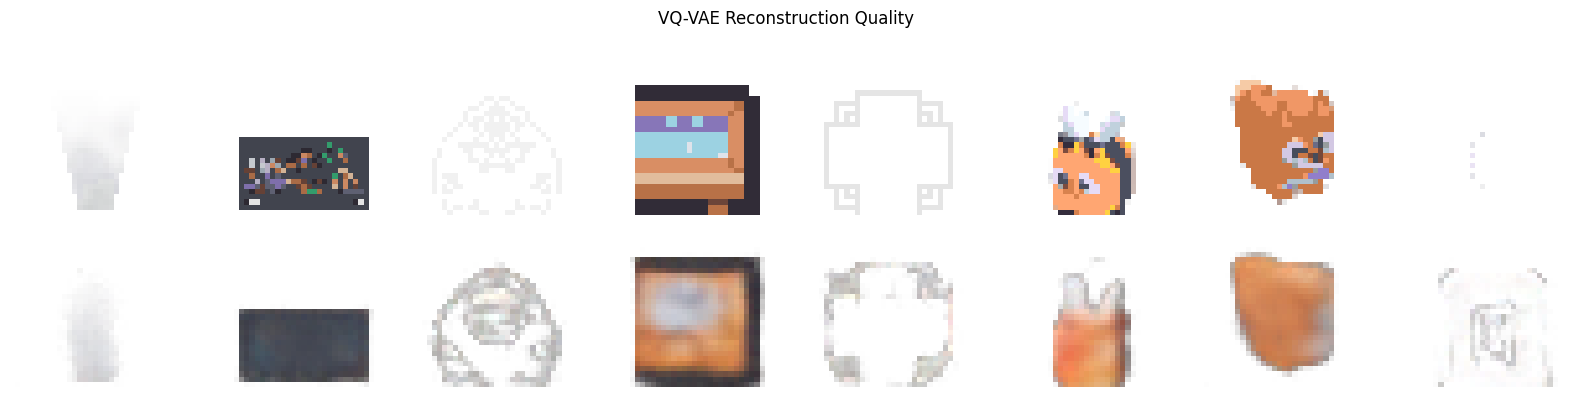

In [23]:
import matplotlib.pyplot as plt
from collections import Counter

# --- 1. Codebook usage ---
sample_loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
usage = Counter()
n_batches_to_check = 20  # ~20*128 = 2560 sprites, enough for a stable estimate

with torch.no_grad():
    for i, batch in enumerate(sample_loader):
        if i >= n_batches_to_check:
            break
        batch = batch.to(device)
        indices = vqvae.encode_to_indices(batch)  # adjust if your method name differs
        usage.update(indices.flatten().cpu().tolist())

codebook_size = 512
used = len(usage)
print(f"Codebook usage: {used}/{codebook_size} codes used ({100*used/codebook_size:.1f}%)")
print(f"Top 10 most-used codes: {usage.most_common(10)}")
print(f"Bottom 10 (of used) codes: {usage.most_common()[-10:]}")

if used / codebook_size < 0.5:
    print("⚠️  WARNING: <50% codebook usage — likely collapse. Sprites/tokens may be degenerate.")
else:
    print("✅ Codebook usage looks healthy.")

# --- 2. Visual reconstruction comparison ---
vqvae.eval()
n_show = 8
sample_batch = next(iter(sample_loader))[:n_show].to(device)

with torch.no_grad():
    out = vqvae(sample_batch)
    recon = out["recon"] if "recon" in out else out["x_recon"]  # adjust key if needed

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4))
for i in range(n_show):
    orig = sample_batch[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    rec = recon[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, i].imshow(orig)
    axes[0, i].axis("off")
    axes[1, i].imshow(rec)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
plt.suptitle("VQ-VAE Reconstruction Quality")
plt.tight_layout()
plt.show()

# Step 3: Encode all sprites through VQ-VAE

In [9]:
vqvae.eval()
dataset_hf = load_dataset(HF_DATASET, split="train")

CLASS_VOCAB = ["unknown","character","item","tile","enemy","player","weapon","food",
               "vehicle","building","decoration","effect","projectile","animal","plant",
               "furniture","tool","accessory","ui_element","terrain"]
ACTION_VOCAB = ["idle","walk","run","attack","jump","hurt","death","block","shoot",
                "cast","interact","fly","swim","climb"]
DIRECTION_VOCAB = ["front","back","left","right","front_left","front_right","back_left","back_right"]

def encode_cond(value, vocab):
    try: return vocab.index(value)
    except ValueError: return 0

all_tokens, all_class, all_action, all_direction = [], [], [], []
for item in tqdm(dataset_hf, desc="Encoding tokens"):
    img = item["image"].convert("RGBA").resize((32, 32), Image.NEAREST)
    img_t = torch.tensor(np.array(img).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        tokens = vqvae.encode_to_indices(img_t).squeeze(0).cpu()
    all_tokens.append(tokens)
    all_class.append(encode_cond(item.get("class","unknown"), CLASS_VOCAB))
    all_action.append(encode_cond(item.get("action","idle"), ACTION_VOCAB))
    all_direction.append(encode_cond(item.get("direction","front"), DIRECTION_VOCAB))

token_data = {
    "tokens": torch.stack(all_tokens).numpy(),
    "class": np.array(all_class),
    "action": np.array(all_action),
    "direction": np.array(all_direction),
}
np.savez("/kaggle/working/token_dataset.npz", **token_data)
print(f"Saved {len(all_tokens)} token sequences")

Encoding tokens: 100%|██████████| 26894/26894 [00:49<00:00, 545.77it/s]

Saved 26894 token sequences


# Step 4: Train Transformer with Warmup + CosineAnnealingLR

In [10]:
from torch.utils.data import TensorDataset, DataLoader
from models.transformer.model import SpriteTransformer

data = np.load("/kaggle/working/token_dataset.npz")
tokens = torch.tensor(data["tokens"])
class_ids = torch.tensor(data["class"])
action_ids = torch.tensor(data["action"])
direction_ids = torch.tensor(data["direction"])

train_ds = TensorDataset(tokens, class_ids, action_ids, direction_ids)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Scaled Transformer: d_model=512, n_heads=8
transformer = SpriteTransformer(
    vocab_size=512,
    condition_vocab_size=64,
    d_model=512,
    n_layers=8,
    n_heads=8,
    max_seq_len=tokens.shape[1] + 1,
).to(device)

optimizer_t = torch.optim.Adam(transformer.parameters(), lr=LR)

# Linear warmup for 10 epochs then cosine decay
warmup_epochs = 10
def warmup_cosine_schedule(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    return 0.5 * (1 + math.cos((epoch - warmup_epochs) / (TRANSFORMER_EPOCHS - warmup_epochs) * math.pi))

scheduler_t = torch.optim.lr_scheduler.LambdaLR(optimizer_t, warmup_cosine_schedule)

ckpt_dir_t = Path("/kaggle/working/checkpoints/transformer")
ckpt_dir_t.mkdir(parents=True, exist_ok=True)

for epoch in range(TRANSFORMER_EPOCHS):
    transformer.train()
    total_loss = 0
    pbar = tqdm(train_dl, desc=f"Transformer Epoch {epoch+1}/{TRANSFORMER_EPOCHS}")
    for batch_tokens, c, a, d in pbar:
        batch_tokens, c, a, d = batch_tokens.to(device), c.to(device), a.to(device), d.to(device)
        optimizer_t.zero_grad()
        logits = transformer(batch_tokens, c, a, d)
        loss = nn.functional.cross_entropy(logits.view(-1, logits.size(-1)), batch_tokens.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(transformer.parameters(), 1.0)
        optimizer_t.step()
        total_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})
    scheduler_t.step()
    avg_loss = total_loss / len(train_dl)
    current_lr = optimizer_t.param_groups[0]["lr"]
    print(f"Transformer Epoch {epoch+1}: loss={avg_loss:.6f} lr={current_lr:.2e}")
    if (epoch + 1) % 10 == 0:
        ckpt_path_t = ckpt_dir_t / f"transformer_epoch_{epoch+1:03d}.pt"
        torch.save({"epoch": epoch, "model_state": transformer.state_dict(), "optimizer_state": optimizer_t.state_dict(), "loss": avg_loss, "config": {"d_model": 512, "n_layers": 8, "n_heads": 8, "max_seq_len": tokens.shape[1] + 1}}, ckpt_path_t)
        if HF_TOKEN:
            from huggingface_hub import HfApi
            HfApi(token=HF_TOKEN).upload_file(path_or_fileobj=str(ckpt_path_t), path_in_repo="transformer_latest.pt", repo_id=HF_MODEL_REPO, repo_type="model")
            print(f"  -> Pushed transformer checkpoint to HF (epoch {epoch+1})")

torch.save({"epoch": TRANSFORMER_EPOCHS-1, "model_state": transformer.state_dict(), "optimizer_state": optimizer_t.state_dict(), "loss": avg_loss, "config": {"d_model": 512, "n_layers": 8, "n_heads": 8, "max_seq_len": tokens.shape[1] + 1}}, ckpt_dir_t / "transformer_final.pt")
if HF_TOKEN:
    from huggingface_hub import HfApi
    HfApi(token=HF_TOKEN).upload_file(path_or_fileobj=str(ckpt_dir_t / "transformer_final.pt"), path_in_repo="transformer_latest.pt", repo_id=HF_MODEL_REPO, repo_type="model")
    print("Transformer final checkpoint pushed to HF")
print("Transformer training complete!")

Transformer Epoch 1/100:  84%|████████▍ | 178/211 [01:13<00:13,  2.42it/s, loss=4.64]


KeyboardInterrupt: 

# Step 5: Push Training Complete Marker to HF Hub

In [ ]:
if HF_TOKEN:
    from huggingface_hub import HfApi
    HfApi(token=HF_TOKEN).upload_file(
        path_or_fileobj=json.dumps({"status": "complete", "vqvae_epochs": VQVAE_EPOCHS, "transformer_epochs": TRANSFORMER_EPOCHS}).encode(),
        path_in_repo="training_complete.json",
        repo_id=HF_MODEL_REPO, repo_type="model",
    )
    print("Training marker pushed to HF")

print("=== ALL DONE ===")